In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.power import TTestPower

# 1. Load your data
df = pd.read_csv('./first_trial.csv')
df1 = pd.read_csv('./third.csv')

# 2. Calculate the difference for each prompt
diff = df['llama-3b'] - df1['llama-3b']

# 3. Calculate Cohen's d for Paired Samples
mean_diff = diff.mean()
std_diff = diff.std()
cohen_d = mean_diff / std_diff

print(f"Observed Cohen's d: {cohen_d:.4f}")

# 4. Use statsmodels to find the required TOTAL prompts
analysis = TTestPower()
required_n = analysis.solve_power(
    effect_size=cohen_d, 
    nobs=None, 
    alpha=0.05, 
    power=0.80
)

print(f"Total prompts needed for 80% power: {round(required_n)}")

Observed Cohen's d: 0.3318
Total prompts needed for 80% power: 73


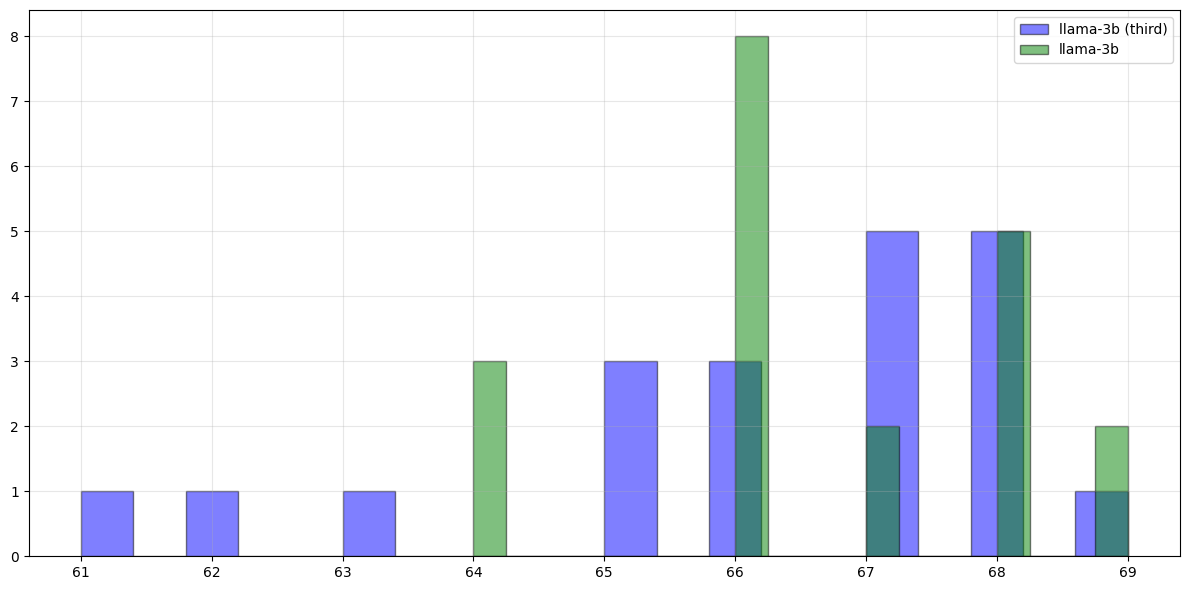

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot overlapping histograms
ax.hist(df1['llama-3b'], bins=20, alpha=0.5, color='blue', edgecolor='black', label='llama-3b (third)')
ax.hist(df['llama-3b'], bins=20, alpha=0.5, color='green', edgecolor='black', label='llama-3b')

ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()